# **SpaceX Falcon 9 First Stage Landing Prediction**
## Machine Learning Prediction

We build a classification pipeline to predict whether the Falcon 9 first stage will land successfully, comparing Logistic Regression, SVM, a Decision Tree, and KNN — each tuned with `GridSearchCV` — and pick the best performer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, jaccard_score, f1_score

In [2]:
def plot_confusion_matrix(y, y_predict, filename=None):
    cm = confusion_matrix(y, y_predict)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

## Load the data

In [3]:
data = pd.read_csv("dataset_part_2.csv")
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
X = pd.read_csv('dataset_part_3.csv')
X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 1: Build the label array `Y`

In [5]:
Y = data['Class'].to_numpy()

## Task 2: Standardize the features

In [6]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

## Task 3: Train/test split

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
Y_test.shape

(18,)

## Task 4: Logistic Regression

In [8]:
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hyperparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8214285714285714


/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/linear_model/_lin

## Task 5: Test accuracy

In [9]:
print("accuracy on test data :", logreg_cv.score(X_test, Y_test))

accuracy on test data : 0.8333333333333334


/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


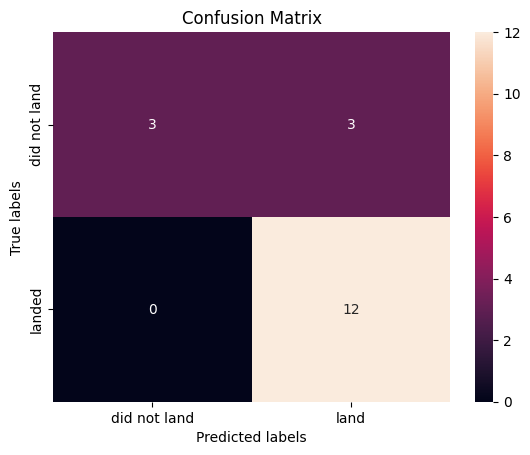

In [10]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'cm_logreg.png')

## Task 6: Support Vector Machine

In [11]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hyperparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142858


## Task 7: Test accuracy

In [12]:
print("accuracy on test data :", svm_cv.score(X_test, Y_test))

accuracy on test data : 0.8333333333333334


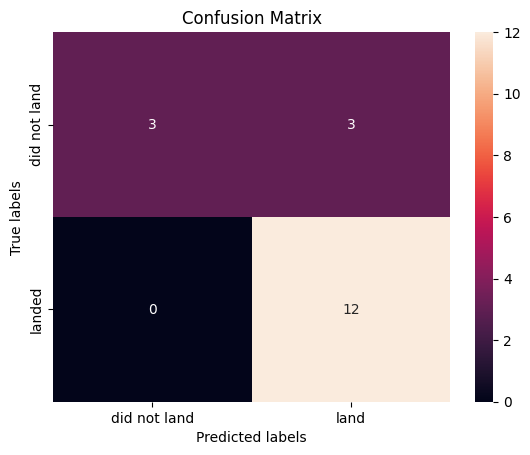

In [13]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'cm_svm.png')

## Task 8: Decision Tree

In [14]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)],
              'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hyperparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
accuracy : 0.8339285714285714


## Task 9: Test accuracy

In [15]:
print("accuracy on test data :", tree_cv.score(X_test, Y_test))

accuracy on test data : 0.7222222222222222


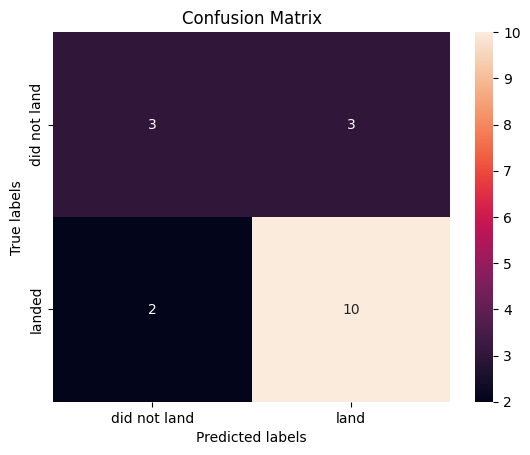

In [16]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'cm_tree.png')

## Task 10: K Nearest Neighbors

In [17]:
parameters = {'n_neighbors': list(range(1, 11)),
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hyperparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

tuned hyperparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
accuracy : 0.8339285714285714


## Task 11: Test accuracy

In [18]:
print("accuracy on test data :", knn_cv.score(X_test, Y_test))

accuracy on test data : 0.8333333333333334


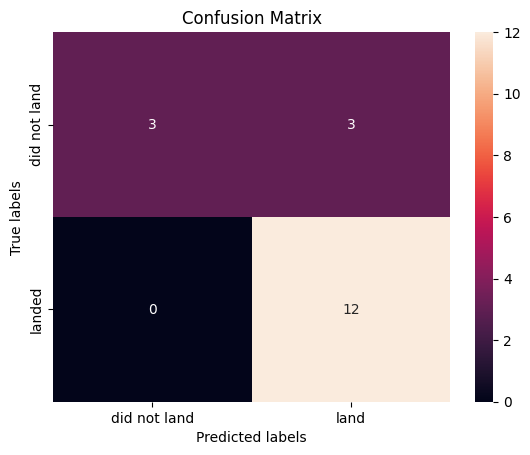

In [19]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'cm_knn.png')

## Task 12: Which method performs best?

In [20]:
algorithms = {'KNN': knn_cv.best_score_,
              'Tree': tree_cv.best_score_,
              'LogisticRegression': logreg_cv.best_score_,
              'SVM': svm_cv.best_score_}
test_scores = {'KNN': knn_cv.score(X_test, Y_test),
               'Tree': tree_cv.score(X_test, Y_test),
               'LogisticRegression': logreg_cv.score(X_test, Y_test),
               'SVM': svm_cv.score(X_test, Y_test)}

comparison = pd.DataFrame({'CV Accuracy': algorithms, 'Test Accuracy': test_scores}).sort_values('CV Accuracy', ascending=False)
comparison.to_csv('model_comparison.csv')
print(comparison)

best_algorithm = max(algorithms, key=algorithms.get)
print('\nBest Algorithm is', best_algorithm, 'with a CV score of', algorithms[best_algorithm])

                    CV Accuracy  Test Accuracy
SVM                    0.848214       0.833333
KNN                    0.833929       0.833333
Tree                   0.833929       0.722222
LogisticRegression     0.821429       0.833333

Best Algorithm is SVM with a CV score of 0.8482142857142858


/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/claude-501/-Users-biancachacon-Documents-PYTHON/3414aaf3-efa4-495a-912b-ce28258331ec/scratchpad/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


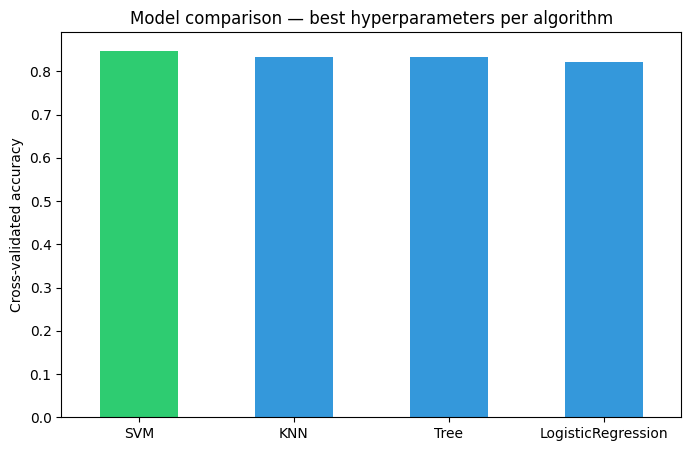

In [21]:
plt.figure(figsize=(8, 5))
comparison['CV Accuracy'].plot(kind='bar', color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison))])
plt.ylabel('Cross-validated accuracy')
plt.title('Model comparison — best hyperparameters per algorithm')
plt.xticks(rotation=0)
plt.savefig('chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()